# Posture Detection V2 — 04 Calibrated 3D Posture Scoring

This notebook turns MotionBERT 3D timelines into confidence-filtered posture features, calibration-relative issue severities, a smoothed 0–100 score, duration tracking, and smart alerts.

> This is an ergonomic research prototype, not a medical diagnostic system. The public demo video produces illustrative pipeline results only.

## 1. Setup and project paths

In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

working_directory = Path.cwd()
if working_directory.name == 'notebooks':
    PROJECT_ROOT = working_directory.parent
elif working_directory.name == 'project_v2':
    PROJECT_ROOT = working_directory
else:
    PROJECT_ROOT = working_directory / 'project_v2'
POSE3D_DIR = PROJECT_ROOT / 'data' / 'poses_3d'
ANNOTATION_DIR = PROJECT_ROOT / 'data' / 'annotations'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'posture_scoring_3d'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_FILE = POSE3D_DIR / 'motionbert_3d_windows_81.npz'
WINDOW_MANIFEST_FILE = POSE3D_DIR / 'motionbert_3d_windows_81_manifest.csv'
TIMELINE_MANIFEST_FILE = PROJECT_ROOT / 'results' / 'motionbert_3d' / 'pose3d_timeline_manifest.csv'
for required in (WINDOW_FILE, WINDOW_MANIFEST_FILE, TIMELINE_MANIFEST_FILE):
    if not required.exists(): raise FileNotFoundError(required)
print('Project root:', PROJECT_ROOT.resolve())

Project root: C:\Users\manth\Desktop\project_v2


## 2. Load 3D windows and reconstruct unique-frame confidence

In [2]:
# Trusted local file generated by Notebook 03; pandas string arrays may use object dtype.
with np.load(WINDOW_FILE, allow_pickle=True) as archive:
    poses3d_windows = archive['poses3d'].astype(np.float32)
    inputs2d_windows = archive['inputs2d'].astype(np.float32)
    window_ids = archive['window_ids'].astype(str)
    joint_names = archive['joint_names'].astype(str)
window_manifest = pd.read_csv(WINDOW_MANIFEST_FILE)
timeline_manifest = pd.read_csv(TIMELINE_MANIFEST_FILE)
if len(window_ids) != len(window_manifest): raise ValueError('Window manifest mismatch.')
if not np.array_equal(window_ids, window_manifest['window_id'].astype(str).to_numpy()): raise ValueError('Window IDs are misaligned.')
print('3D windows:', poses3d_windows.shape)
display(timeline_manifest)

3D windows: (12, 81, 17, 3)


,video_filename,pose3d_file,frames,covered_frames,coverage_rate,fps
0,DEMO_PEXELS_9130469_side_view.mp4,data/poses_3d/DEMO_PEXELS_9130469_side_view_mo...,402,378,0.940299,30.0


## 3. 3D features and confidence gate

Features are scale-normalized by torso or shoulder length. Frames are rejected when key joints are missing, non-finite, or have weak 2D confidence.

In [3]:
J = {name: index for index, name in enumerate(joint_names)}
REQUIRED_JOINTS = [J['pelvis'], J['thorax'], J['head'], J['left_shoulder'], J['right_shoulder']]
MIN_REQUIRED_CONFIDENCE = 0.25
SMOOTH_SECONDS = 0.5
BAD_SCORE_THRESHOLD = 70.0
ALERT_AFTER_SECONDS = 5.0

def safe_norm(vector):
    return np.maximum(np.linalg.norm(vector, axis=-1), 1e-6)

def angle_degrees(first, second):
    denominator = safe_norm(first) * safe_norm(second)
    cosine = np.sum(first * second, axis=-1) / denominator
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_features(pose, confidence):
    pelvis, thorax = pose[:, J['pelvis']], pose[:, J['thorax']]
    head = pose[:, J['head']]
    left_shoulder, right_shoulder = pose[:, J['left_shoulder']], pose[:, J['right_shoulder']]
    torso = thorax - pelvis
    head_vector = head - thorax
    shoulder_vector = left_shoulder - right_shoulder
    torso_length, shoulder_width = safe_norm(torso), safe_norm(shoulder_vector)
    frame = pd.DataFrame({
        'head_depth': head_vector[:, 2] / torso_length,
        'head_lateral': head_vector[:, 0] / torso_length,
        'neck_angle_deg': angle_degrees(head_vector, torso),
        'torso_lateral': torso[:, 0] / torso_length,
        'torso_depth': torso[:, 2] / torso_length,
        'shoulder_tilt': (left_shoulder[:, 1] - right_shoulder[:, 1]) / shoulder_width,
        'torso_length': torso_length, 'shoulder_width': shoulder_width,
        'required_confidence': np.nanmin(confidence[:, REQUIRED_JOINTS], axis=1),
    })
    numeric_finite = np.isfinite(frame.drop(columns='required_confidence')).all(axis=1)
    frame['valid_pose'] = numeric_finite & frame['required_confidence'].ge(MIN_REQUIRED_CONFIDENCE)
    return frame
print('Required joints:', [joint_names[index] for index in REQUIRED_JOINTS])

Required joints: ['pelvis', 'thorax', 'head', 'left_shoulder', 'right_shoulder']


## 4. Personal calibration

The preferred baseline is the upright interval recorded in `sessions.csv`. If it is absent, the first three valid seconds are used only as a development fallback and clearly marked.

In [4]:
SESSIONS_FILE = ANNOTATION_DIR / 'sessions.csv'
sessions = pd.read_csv(SESSIONS_FILE) if SESSIONS_FILE.exists() else pd.DataFrame()
FEATURES = ['head_depth', 'head_lateral', 'neck_angle_deg', 'torso_lateral', 'torso_depth', 'shoulder_tilt']
FLOORS = {'head_depth': .08, 'head_lateral': .06, 'neck_angle_deg': 8.0, 'torso_lateral': .06, 'torso_depth': .08, 'shoulder_tilt': .05}

def calibration_mask(video_filename, frame, fps):
    if len(sessions) and 'video_filename' in sessions.columns:
        match = sessions.loc[sessions['video_filename'].eq(video_filename)]
        if len(match) == 1:
            start = pd.to_numeric(match.iloc[0].get('calibration_start_seconds'), errors='coerce')
            end = pd.to_numeric(match.iloc[0].get('calibration_end_seconds'), errors='coerce')
            if np.isfinite(start) and np.isfinite(end) and end > start:
                return frame['seconds'].between(start, end, inclusive='left') & frame['valid_pose'], 'session_manifest'
    valid_indices = np.flatnonzero(frame['valid_pose'].to_numpy())
    mask = np.zeros(len(frame), dtype=bool)
    mask[valid_indices[:max(1, round(3 * fps))]] = True
    return pd.Series(mask, index=frame.index), 'first_3_valid_seconds_fallback'

def robust_baseline(frame, mask):
    selected = frame.loc[mask, FEATURES]
    if len(selected) < 15: raise RuntimeError('Fewer than 15 valid calibration frames.')
    median = selected.median()
    mad = (selected - median).abs().median()
    scale = pd.Series({name: max(1.4826 * mad[name], FLOORS[name]) for name in FEATURES})
    return median, scale

## 5. Issue severities, 0–100 score, smoothing, and sustained alerts

In [5]:
def severity(delta, scale):
    return np.clip((np.abs(delta) / scale - 1.0) / 2.0, 0.0, 1.0)

def running_duration(mask, fps):
    output = np.zeros(len(mask), dtype=float); count = 0
    for index, active in enumerate(np.asarray(mask, dtype=bool)):
        count = count + 1 if active else 0
        output[index] = count / fps
    return output

all_frames, summaries, baselines = [], [], {}
for _, video_row in timeline_manifest.iterrows():
    video = video_row['video_filename']; fps = float(video_row['fps'])
    with np.load(PROJECT_ROOT / video_row['pose3d_file'], allow_pickle=False) as archive:
        pose = archive['poses3d'].astype(np.float32); covered = archive['covered_mask'].astype(bool)
    confidence_sum = np.zeros((len(pose), 17), dtype=float); confidence_count = np.zeros((len(pose), 1), dtype=float)
    rows = window_manifest.loc[window_manifest['video_filename'].eq(video)]
    for manifest_index, row in rows.iterrows():
        window_index = int(np.flatnonzero(window_ids == str(row['window_id']))[0])
        start, end = int(row['start_frame']), int(row['end_frame_exclusive'])
        confidence_sum[start:end] += inputs2d_windows[window_index, :, :, 2]
        confidence_count[start:end] += 1
    confidence = np.divide(confidence_sum, confidence_count, out=np.zeros_like(confidence_sum), where=confidence_count > 0)
    frame = extract_features(pose, confidence)
    frame['valid_pose'] &= covered
    frame.insert(0, 'frame', np.arange(len(frame))); frame.insert(1, 'seconds', np.arange(len(frame)) / fps)
    frame.insert(0, 'video_filename', video)
    calibration, source = calibration_mask(video, frame, fps)
    baseline, scale = robust_baseline(frame, calibration)
    baselines[video] = {'source': source, 'median': baseline.to_dict(), 'robust_scale': scale.to_dict()}
    frame['forward_head_severity'] = severity(frame['head_depth'] - baseline['head_depth'], scale['head_depth'])
    frame['slouching_severity'] = np.maximum(severity(frame['neck_angle_deg'] - baseline['neck_angle_deg'], scale['neck_angle_deg']), severity(frame['torso_depth'] - baseline['torso_depth'], scale['torso_depth']))
    frame['leaning_severity'] = severity(frame['torso_lateral'] - baseline['torso_lateral'], scale['torso_lateral'])
    frame['shoulder_imbalance_severity'] = severity(frame['shoulder_tilt'] - baseline['shoulder_tilt'], scale['shoulder_tilt'])
    issue_columns = ['forward_head_severity','slouching_severity','leaning_severity','shoulder_imbalance_severity']
    penalty = frame[issue_columns].mul([.30, .35, .20, .15]).sum(axis=1)
    frame['posture_score_raw'] = np.clip(100 * (1 - penalty), 0, 100)
    smooth_frames = max(3, round(SMOOTH_SECONDS * fps))
    frame['posture_score'] = frame['posture_score_raw'].rolling(smooth_frames, min_periods=1).median()
    frame.loc[~frame['valid_pose'], ['posture_score_raw','posture_score'] + issue_columns] = np.nan
    frame['bad_posture'] = frame['valid_pose'] & frame['posture_score'].lt(BAD_SCORE_THRESHOLD)
    frame['bad_duration_seconds'] = running_duration(frame['bad_posture'], fps)
    frame['smart_alert'] = frame['bad_duration_seconds'].ge(ALERT_AFTER_SECONDS)
    severity_values = frame[issue_columns].fillna(-1).to_numpy(); names = np.array(['forward_head','slouching','leaning','shoulder_imbalance'])
    frame['dominant_issue'] = np.where(frame['valid_pose'], names[np.argmax(severity_values, axis=1)], 'low_confidence')
    all_frames.append(frame)
    valid = frame.loc[frame['valid_pose']]
    summaries.append({'video_filename': video, 'calibration_source': source, 'valid_frame_rate': float(frame['valid_pose'].mean()), 'mean_posture_score': float(valid['posture_score'].mean()), 'good_posture_percent': float(valid['posture_score'].ge(BAD_SCORE_THRESHOLD).mean() * 100), 'bad_posture_seconds': float(valid['bad_posture'].sum() / fps), 'alerts_triggered': int(valid['smart_alert'].sum() > 0), 'most_common_issue': valid['dominant_issue'].mode().iat[0] if len(valid) else 'none'})
frame_results = pd.concat(all_frames, ignore_index=True); session_summary = pd.DataFrame(summaries)
display(session_summary)

,video_filename,calibration_source,valid_frame_rate,mean_posture_score,good_posture_percent,bad_posture_seconds,alerts_triggered,most_common_issue
0,DEMO_PEXELS_9130469_side_view.mp4,first_3_valid_seconds_fallback,0.940299,98.464396,100.0,0.0,0,forward_head


## 6. Timeline dashboard

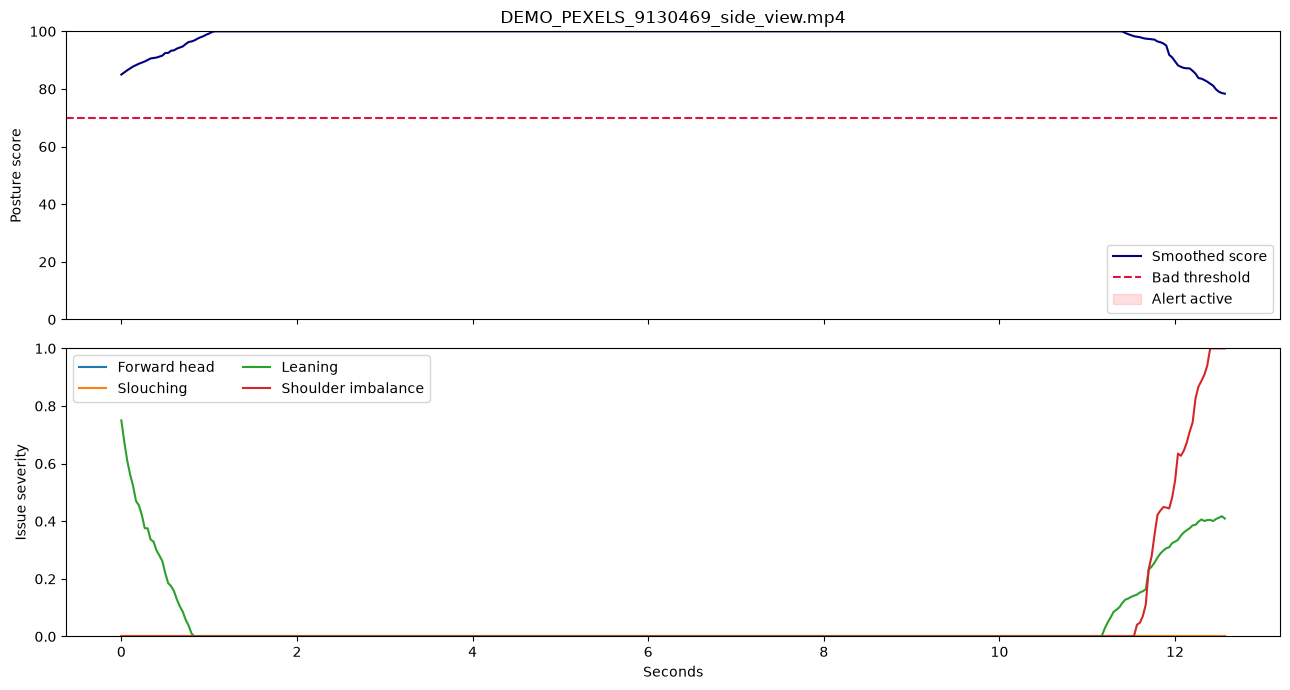

In [6]:
for video, frame in frame_results.groupby('video_filename'):
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(frame['seconds'], frame['posture_score'], label='Smoothed score', color='navy')
    axes[0].axhline(BAD_SCORE_THRESHOLD, color='crimson', linestyle='--', label='Bad threshold')
    axes[0].fill_between(frame['seconds'], 0, 100, where=frame['smart_alert'], color='red', alpha=.12, label='Alert active')
    axes[0].set_ylim(0, 100); axes[0].set_ylabel('Posture score'); axes[0].legend(loc='lower right'); axes[0].set_title(video)
    for column, label in [('forward_head_severity','Forward head'),('slouching_severity','Slouching'),('leaning_severity','Leaning'),('shoulder_imbalance_severity','Shoulder imbalance')]:
        axes[1].plot(frame['seconds'], frame[column], label=label)
    axes[1].set_ylim(0, 1); axes[1].set_ylabel('Issue severity'); axes[1].set_xlabel('Seconds'); axes[1].legend(ncol=2)
    plt.tight_layout(); plt.show()

## 7. Save analytics and calibration records

In [7]:
FRAME_RESULTS_FILE = RESULTS_DIR / 'posture_timeline.csv'
SUMMARY_FILE = RESULTS_DIR / 'session_summary.csv'
CALIBRATION_FILE = RESULTS_DIR / 'calibration_baselines.json'
frame_results.to_csv(FRAME_RESULTS_FILE, index=False)
session_summary.to_csv(SUMMARY_FILE, index=False)
with CALIBRATION_FILE.open('w') as file:
    json.dump({'created_utc': datetime.now(timezone.utc).isoformat(), 'minimum_required_confidence': MIN_REQUIRED_CONFIDENCE, 'bad_score_threshold': BAD_SCORE_THRESHOLD, 'alert_after_seconds': ALERT_AFTER_SECONDS, 'baselines': baselines}, file, indent=2)
print('Saved:', FRAME_RESULTS_FILE.resolve())
print('Saved:', SUMMARY_FILE.resolve())
print('Saved:', CALIBRATION_FILE.resolve())

Saved: C:\Users\manth\Desktop\project_v2\results\posture_scoring_3d\posture_timeline.csv
Saved: C:\Users\manth\Desktop\project_v2\results\posture_scoring_3d\session_summary.csv
Saved: C:\Users\manth\Desktop\project_v2\results\posture_scoring_3d\calibration_baselines.json


## Interpretation and next step

For the public demo, treat scores and issue names as a software test—not accuracy evidence. A valid evaluation requires consented participants, explicit upright calibration, temporal issue labels, and participant-independent splits.

**Notebook 05** will package the pipeline into session-level inference with temporal state, alert cooldown, history export, and a dashboard-ready data stream. A learned issue classifier should be added only after labelled participant videos are collected.